 SARIMAX with Temperature

This notebook extends the SARIMA model of Part 3 by adding temperature as an
exogenous regressor, forming a SARIMAX model. Electricity demand is strongly
weather-driven, so temperature should carry explanatory power.

Because observed future temperature is used over the test period, the resulting
forecast is a **conditional (explanatory) forecast** rather than a true
operational forecast: in practice, future temperature would itself have to be
predicted from a weather forecast.

## Setup

We mount Google Drive, clone the repository, bring in the dataset, and make the
`electricity_demand` package importable.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, shutil, sys

# Clone the repository if the runtime has been reset
if not os.path.exists("/content/electricity-demand-forecasting"):
    !git clone https://github.com/iisratislam/electricity-demand-forecasting.git

%cd /content/electricity-demand-forecasting

# Copy the dataset in from Drive (it is not committed to the repository)
os.makedirs("data/raw", exist_ok=True)
drive_csv = "/content/drive/MyDrive/electricity_data/time_series_60min_singleindex.csv"
target    = "data/raw/time_series_60min_singleindex.csv"
if not os.path.exists(target):
    shutil.copy(drive_csv, target)

# Make the src package importable
sys.path.append("src")
print("Environment ready.")

Cloning into 'electricity-demand-forecasting'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 85 (delta 25), reused 67 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 2.48 MiB | 21.36 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/electricity-demand-forecasting
Environment ready.


## Loading data and recreating the train/test split

We rebuild the weekly mean-load series and apply the same 104-week (two-year)
chronological split used throughout this study. Keeping the split identical across
all parts ensures the SARIMAX results are directly comparable with the benchmarks
and the plain SARIMA model.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_demand.data import load_raw_load, to_weekly_gw

# Rebuild the weekly mean-load series (GW)
weekly = to_weekly_gw(load_raw_load("data/raw/time_series_60min_singleindex.csv"))

TEST_WEEKS = 104
train = weekly.iloc[:-TEST_WEEKS]
test  = weekly.iloc[-TEST_WEEKS:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} weeks)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} weeks)")

Train: 2015-01-04 -> 2018-10-07 (197 weeks)
Test : 2018-10-14 -> 2020-10-04 (104 weeks)


## Fetching temperature data

Electricity demand responds strongly to temperature. We retrieve daily mean
temperature for Berlin — a representative location for German demand — from the
Open-Meteo historical archive API, then aggregate it to weekly features.

From the daily temperature we derive:
- **temp_mean, temp_min, temp_max** — weekly summaries of temperature level.
- **heating degree days (HDD)** — accumulated coldness below a comfort threshold,
  capturing heating demand.
- **cooling degree days (CDD)** — accumulated heat above a comfort threshold,
  capturing cooling demand.

Degree-day features are standard in energy modelling because demand responds
non-linearly to temperature: both very cold and very hot weeks raise demand.

This logic is written to `src/electricity_demand/features.py` for reuse.

In [6]:
%%writefile src/electricity_demand/features.py
"""
features.py
-----------
Temperature feature engineering for the electricity demand study.

Daily mean temperature for a representative location (Berlin) is downloaded from
the Open-Meteo historical archive API and converted into weekly features,
including heating and cooling degree days.
"""

from __future__ import annotations
import requests
import numpy as np
import pandas as pd


def get_open_meteo_temperature(
    latitude: float = 52.52,
    longitude: float = 13.41,
    start_date: str = "2015-01-01",
    end_date: str = "2020-12-31",
) -> pd.DataFrame:
    """
    Download daily mean temperature from the Open-Meteo archive API.

    Parameters
    ----------
    latitude, longitude : float
        Location coordinates. Defaults to Berlin (52.52 N, 13.41 E).
    start_date, end_date : str
        Inclusive date range in YYYY-MM-DD format.

    Returns
    -------
    pd.DataFrame
        Daily mean temperature (deg C), indexed by timezone-naive date.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()["daily"]

    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    }).set_index("date")

    return temp


def build_weekly_temperature_features(
    temp_daily: pd.DataFrame,
    weekly_index: pd.Index,
    base_heat: float = 15.5,
    base_cool: float = 22.0,
) -> pd.DataFrame:
    """
    Convert daily temperature into weekly temperature features.

    The daily temperature index is aligned to the timezone of the weekly load
    index before resampling, so the resulting features match the load series.

    Parameters
    ----------
    temp_daily : pd.DataFrame
        Daily mean temperature, indexed by date (from get_open_meteo_temperature).
    weekly_index : pd.Index
        The weekly (W-SUN) index of the load series, used to align features.
    base_heat : float, default 15.5
        Threshold below which heating demand accrues (deg C).
    base_cool : float, default 22.0
        Threshold above which cooling demand accrues (deg C).

    Returns
    -------
    pd.DataFrame
        Weekly temperature features aligned to weekly_index:
        temp_mean, temp_min, temp_max, heating_degree, cooling_degree.
    """
    t = temp_daily["temperature_2m_mean"].copy()

    # Match the timezone of the load index so resampling aligns correctly
    if weekly_index.tz is not None and t.index.tz is None:
        t.index = t.index.tz_localize(weekly_index.tz)
    elif weekly_index.tz is None and t.index.tz is not None:
        t.index = t.index.tz_localize(None)

    # Resample daily temperature to weekly (W-SUN, matching the load series)
    weekly_mean = t.resample("W").mean()
    weekly_min  = t.resample("W").min()
    weekly_max  = t.resample("W").max()
    hdd = np.maximum(base_heat - t, 0).resample("W").sum()
    cdd = np.maximum(t - base_cool, 0).resample("W").sum()

    feats = pd.DataFrame({
        "temp_mean": weekly_mean,
        "temp_min":  weekly_min,
        "temp_max":  weekly_max,
        "heating_degree": hdd,
        "cooling_degree": cdd,
    })

    # Reindex onto the exact load weekly index; interpolate any small gaps
    feats = feats.reindex(weekly_index).interpolate("time")
    return feats

Overwriting src/electricity_demand/features.py


### Downloading and aligning temperature features

We fetch Berlin's daily temperature over the same period as the load data, then
aggregate it to the weekly index. The API call requires an internet connection;
the resulting features are aligned to the weekly load series so they can be used
as exogenous regressors.

In [7]:
import importlib
import electricity_demand.features as feat_module
importlib.reload(feat_module)
from electricity_demand.features import get_open_meteo_temperature, build_weekly_temperature_features

# Fetch daily Berlin temperature over the load period
temp_daily = get_open_meteo_temperature(
    start_date=str(weekly.index.min().date()),
    end_date=str(weekly.index.max().date()),
)

# Aggregate to weekly features aligned to the load series index
temp_weekly = build_weekly_temperature_features(temp_daily, weekly.index)

print(f"Weekly temperature rows : {len(temp_weekly)}")
print(f"\nMissing values per feature:\n{temp_weekly.isna().sum()}")
print(f"\nFirst few rows:")
print(temp_weekly.head().round(2).to_string())

Weekly temperature rows : 301

Missing values per feature:
temp_mean         0
temp_min          0
temp_max          0
heating_degree    0
cooling_degree    0
dtype: int64

First few rows:
                           temp_mean  temp_min  temp_max  heating_degree  cooling_degree
date                                                                                    
2015-01-04 00:00:00+00:00       3.00       3.0       3.0            12.5             0.0
2015-01-11 00:00:00+00:00       3.89       1.2       8.5            81.3             0.0
2015-01-18 00:00:00+00:00       4.90      -0.8       9.2            74.2             0.0
2015-01-25 00:00:00+00:00       0.03      -0.7       0.9           108.3             0.0
2015-02-01 00:00:00+00:00       1.41      -0.1       2.8            98.6             0.0


## Examining the temperature–demand relationship

Before modelling, we visualise how weekly electricity demand relates to
temperature. Energy theory predicts that in a heating-dominated climate like
Germany, demand rises as temperature falls (heating), with a weaker rise at high
temperatures (cooling).

Confirming this relationship justifies including temperature as an exogenous
regressor in the SARIMAX model.

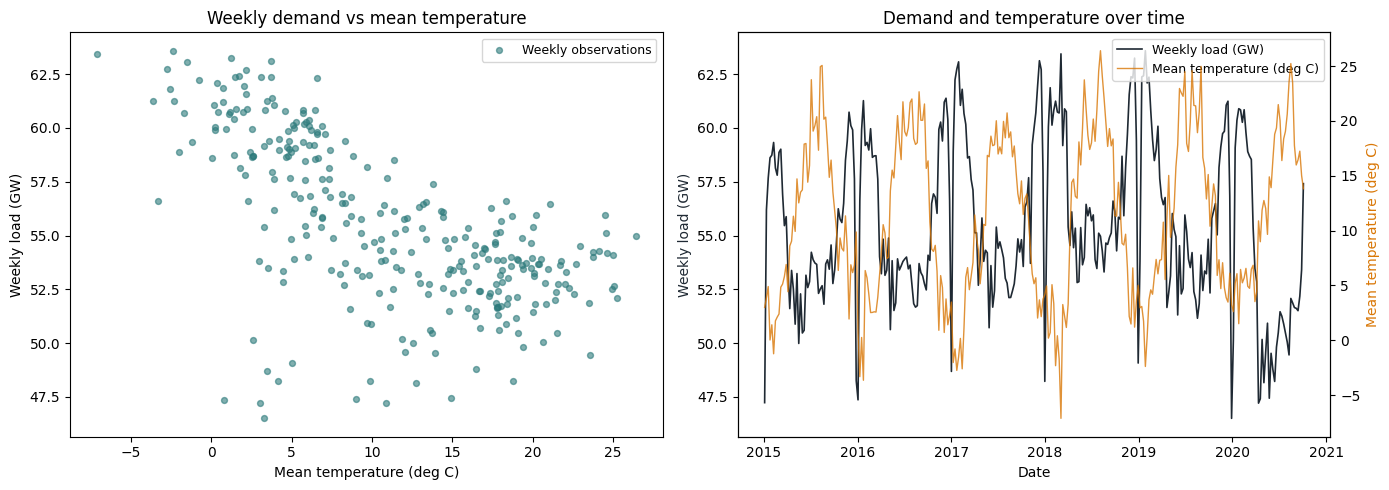

Correlation of weekly load with temperature features:
temp_mean        -0.637
temp_min         -0.626
temp_max         -0.623
heating_degree    0.694
cooling_degree   -0.159


In [10]:
# Merge weekly load with the temperature features
feature_df = pd.DataFrame({"load_gw": weekly}).join(temp_weekly)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of demand vs mean temperature
axes[0].scatter(feature_df["temp_mean"], feature_df["load_gw"],
                s=18, alpha=0.6, color="#2C7A7B", label="Weekly observations")
axes[0].set_title("Weekly demand vs mean temperature")
axes[0].set_xlabel("Mean temperature (deg C)")
axes[0].set_ylabel("Weekly load (GW)")
axes[0].legend(loc="upper right", fontsize=9)

# Right: load and temperature over time (twin axes)
ax1 = axes[1]
ax2 = ax1.twinx()
line1, = ax1.plot(feature_df.index, feature_df["load_gw"],
                  color="#1F2933", lw=1.2, label="Weekly load (GW)")
line2, = ax2.plot(feature_df.index, feature_df["temp_mean"],
                  color="#D97706", lw=1.0, alpha=0.8, label="Mean temperature (deg C)")

ax1.set_title("Demand and temperature over time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Weekly load (GW)", color="#1F2933")
ax2.set_ylabel("Mean temperature (deg C)", color="#D97706")

# Combine both lines into a single legend (needed for twin axes)
ax1.legend(handles=[line1, line2], loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/figures/04_temp_demand_relationship.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation between demand and each temperature feature
print("Correlation of weekly load with temperature features:")
print(feature_df.corr()["load_gw"].drop("load_gw").round(3).to_string())

## Building the SARIMAX model with temperature

We add temperature features as exogenous regressors to the SARIMA structure from
Part 3, forming a SARIMAX model. We use the parsimonious non-seasonal order (0,1,1)
with seasonal order (0,1,1,52), since Part 3 showed this specification had
well-identified parameters and white-noise residuals — a sounder basis for adding
covariates than the over-parameterised six-term model.

The exploratory analysis showed heating degree days most strongly associated with
demand (r = 0.69) and cooling only weakly (r = -0.16), reflecting Germany's
heating-dominated climate. We include mean temperature and both degree-day
features, which capture distinct aspects of the demand response, while avoiding
the near-collinear temp_min and temp_max.

**Important caveat on data leakage.** The exogenous regressors for the test period
are *observed* temperatures. In genuine operational forecasting these would be
unknown and would themselves require a weather forecast. The resulting forecast is
therefore a **conditional (explanatory) forecast**: it answers "given the actual
weather, how well can demand be explained?" rather than "what will demand be?".

In [11]:
from electricity_demand.models.sarimax import fit_sarimax, forecast_sarimax

# Exogenous regressors: temperature level plus heating/cooling degree days
EXOG_COLS = ["temp_mean", "heating_degree", "cooling_degree"]

X = feature_df[EXOG_COLS]
X_train = X.iloc[:-TEST_WEEKS]
X_test  = X.iloc[-TEST_WEEKS:]

# Fit SARIMAX with the parsimonious order and exogenous temperature regressors
sarimax_fit = fit_sarimax(
    y_train=train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    X_train=X_train,
)

print(sarimax_fit.summary().tables[1])

                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
temp_mean          0.3082      0.178      1.728      0.084      -0.041       0.658
heating_degree     0.0802      0.027      2.995      0.003       0.028       0.133
cooling_degree    -0.0273      0.089     -0.308      0.758      -0.201       0.146
ma.L1             -1.0000    231.230     -0.004      0.997    -454.202     452.202
ma.S.L52          -0.8159      0.472     -1.729      0.084      -1.741       0.109
sigma2             1.2534    289.776      0.004      0.997    -566.696     569.203


## Forecasting with the conditional SARIMAX model

We forecast the 104-week test period using the observed test-period temperatures
as exogenous inputs. As noted, this is a conditional (explanatory) forecast: it
uses realised weather that would not be known in advance operationally.

We compare the SARIMAX forecast against the plain SARIMA model and the
seasonal-naive benchmark to assess whether temperature information improves
accuracy.

In [12]:
from electricity_demand.models.benchmarks import seasonal_naive_forecast
from electricity_demand.evaluation import evaluate_forecast

h = len(test)

# Conditional forecast using observed test-period temperatures
fc_sarimax, ci_sarimax = forecast_sarimax(
    sarimax_fit, h, test.index, X_test=X_test, alpha=0.05
)

# Rebuild comparators
sn = seasonal_naive_forecast(train, h, 52, test.index)

# Rebuild the plain SARIMA (parsimonious, no temperature) for a fair comparison
from electricity_demand.models.sarimax import fit_sarimax as _fit
sarima_plain = _fit(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 52))
fc_plain, _  = forecast_sarimax(sarima_plain, h, test.index, alpha=0.05)

results = pd.DataFrame([
    evaluate_forecast("seasonal_naive",              test, sn,         train),
    evaluate_forecast("SARIMA(0,1,1)(0,1,1,52)",     test, fc_plain,   train),
    evaluate_forecast("SARIMAX + temperature",       test, fc_sarimax, train),
]).sort_values("MASE").reset_index(drop=True)

print("Forecast accuracy over the 104-week test period:\n")
print(results.round(3).to_string(index=False))

Forecast accuracy over the 104-week test period:

                  model   MAE  RMSE  MASE  Bias
         seasonal_naive 2.319 3.007 1.732 1.732
  SARIMAX + temperature 2.830 3.573 2.114 2.530
SARIMA(0,1,1)(0,1,1,52) 3.296 4.018 2.462 3.090


## SARIMAX forecast against actual demand

The plot compares the temperature-augmented SARIMAX forecast with the plain SARIMA
model, the seasonal-naive benchmark, and realised demand. Although temperature
improves on plain SARIMA, the COVID-19 collapse from March 2020 remains outside all
models' expectations, since it was driven by economic restrictions rather than
weather.

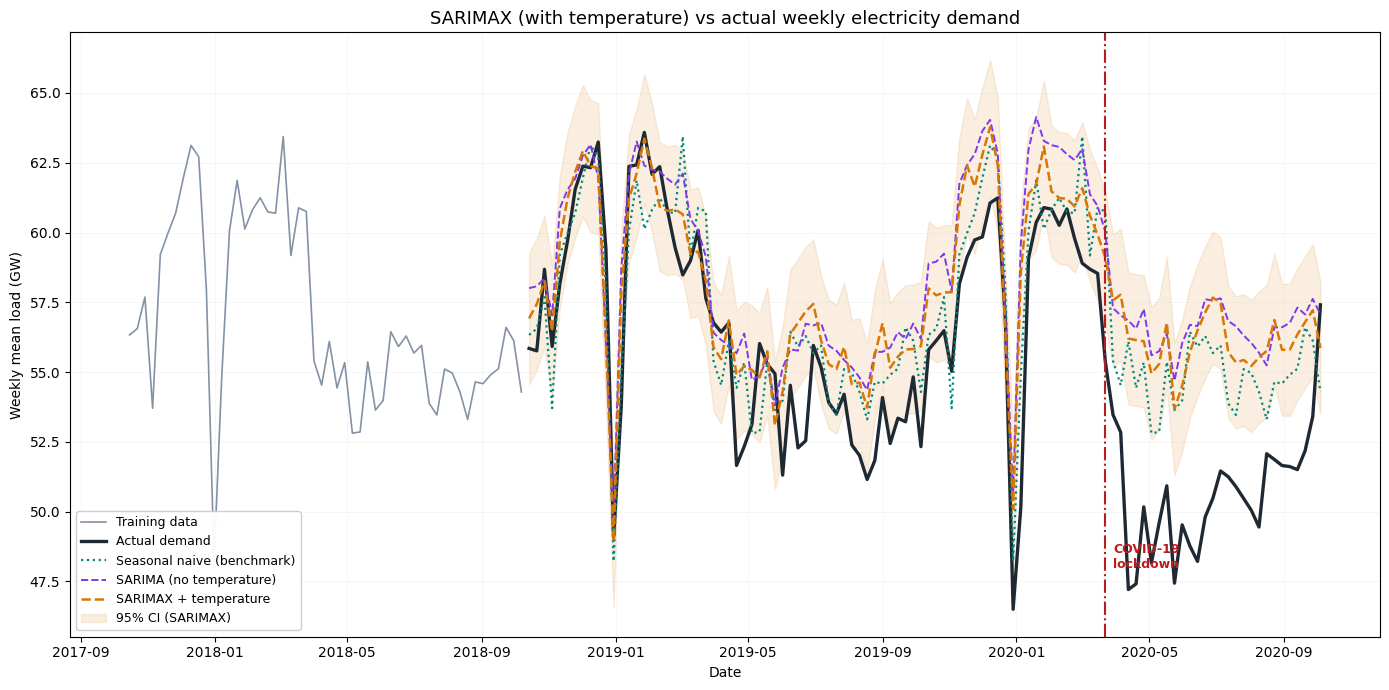

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(train.index[-52:], train.iloc[-52:],
        color="#8492A6", lw=1.2, label="Training data")
ax.plot(test.index, test,
        color="#1F2933", lw=2.4, label="Actual demand")
ax.plot(test.index, sn,
        color="#00897B", lw=1.6, ls=":", label="Seasonal naive (benchmark)")
ax.plot(test.index, fc_plain,
        color="#7C3AED", lw=1.4, ls="--", label="SARIMA (no temperature)")
ax.plot(test.index, fc_sarimax,
        color="#D97706", lw=1.8, ls="--", label="SARIMAX + temperature")

# 95% confidence interval for the SARIMAX model
ax.fill_between(test.index, ci_sarimax.iloc[:, 0], ci_sarimax.iloc[:, 1],
                color="#D97706", alpha=0.12, label="95% CI (SARIMAX)")

ax.axvline(pd.Timestamp("2020-03-22", tz="UTC"), color="#B91C1C", ls="-.", lw=1.5)
ax.text(pd.Timestamp("2020-03-29", tz="UTC"), 48,
        "COVID-19\nlockdown", fontsize=9, color="#B91C1C", weight="bold")

ax.set_title("SARIMAX (with temperature) vs actual weekly electricity demand",
             fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Weekly mean load (GW)")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.15, linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig("outputs/figures/04_sarimax_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
import os
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

sarimax_forecasts = pd.DataFrame({
    "actual":          test,
    "seasonal_naive":  sn,
    "sarima_plain":    fc_plain,
    "sarimax_temp":    fc_sarimax,
    "sarimax_ci_lower": ci_sarimax.iloc[:, 0],
    "sarimax_ci_upper": ci_sarimax.iloc[:, 1],
})
sarimax_forecasts.to_csv("outputs/forecasts/sarimax_forecasts.csv")
results.to_csv("outputs/metrics/sarimax_metrics.csv", index=False)

print("Saved SARIMAX forecasts and metrics")

Saved SARIMAX forecasts and metrics


## Part 4 conclusions

**Temperature meaningfully improves the SARIMA forecast.** Adding mean temperature
and degree-day regressors reduced MASE from 2.462 (plain SARIMA) to 2.114
(SARIMAX), an improvement of roughly 14%, and reduced the positive bias from 3.09
to 2.53 GW. Heating degree days were the strongest and only clearly significant
covariate (coefficient 0.080, p = 0.003), confirming that German demand is
heating-driven. Cooling degree days were not significant (p = 0.758), reflecting
the country's limited use of air-conditioning.

**The improvement comes with an important caveat.** The test-period temperatures
were observed rather than forecast, so this is a conditional (explanatory)
forecast, not a true operational one. Operationally, temperature would itself need
to be predicted, and forecast error in the weather would propagate into the demand
forecast, reducing the benefit shown here.

**Temperature and seasonality partly overlap.** Because temperature is largely the
cause of the annual demand cycle, the exogenous regressors compete with the
seasonal term for the same variance. This destabilised the time-series parameters
(the MA and variance terms became unidentifiable) even as the temperature
coefficient itself became interpretable.

**The benchmark still wins.** Despite the improvement, SARIMAX (MASE 2.114) does
not beat the seasonal-naive benchmark (1.732). Temperature explains ordinary
seasonal variation, but the 2020 demand collapse was caused by COVID-19 economic
restrictions, not weather. No weather covariate can anticipate a structural break
of this kind. This reinforces the central limitation identified in Part 3: history
and weather alone cannot forecast an unprecedented shock.